In [5]:
%matplotlib inline
# tag: remove-cell applied

# Continuous Data with Bayesian Model Averaging

## Table of Contents

- [Single model fit - LOUD](#single-model-fit---loud)
- [Multiple model fit (sessions) - LOUD](#multiple-model-fit-sessions---loud)
- [Running expanded suite analyses](#running-expanded-suite-analyses)

Bayesian model averaging is currently available for continuous datasets in `pybmds`using the Bayesian LOUD 
(Leveraging Objective Univariate Distributions) method.  Here, we describe how to run a continuous 
analysis using a single model, or model averaging using the standard BMDS suite of models or the expanded suite using PROAST or EFSA models.  Additionally, we demonstrate how to plot your results. 

## Single model fit - LOUD

You can run individual models using the Bayesian LOUD approach rather than running all models and finding the model average.

To run the Exponential 5 model: 

     Exponential 5 Model      
══════════════════════════════

Version: pybmds 25.2 (bmdscore 25.2)

Input Summary:
╒══════════════════════════════╤════════════════════════════╕
│ BMR                          │ 1.0 Standard Deviation     │
│ Distribution                 │ Normal + Constant variance │
│ Modeling Direction           │ Up (↑)                     │
│ Confidence Level (one sided) │ 0.95                       │
│ Modeling Approach            │ Bayesian                   │
╘══════════════════════════════╧════════════════════════════╛

Parameter Settings:
╒═════════════╤════════════════╤════════════════════════════════════════════════════════════╕
│ Parameter   │ Distribution   │ Definition                                                 │
╞═════════════╪════════════════╪════════════════════════════════════════════════════════════╡
│ m0          │ Student_t      │ df=19.0, loc=6.0, scale=0.917662935482247                  │
│ m1          │ Student_t      │ df=19.0, loc=30.0, s

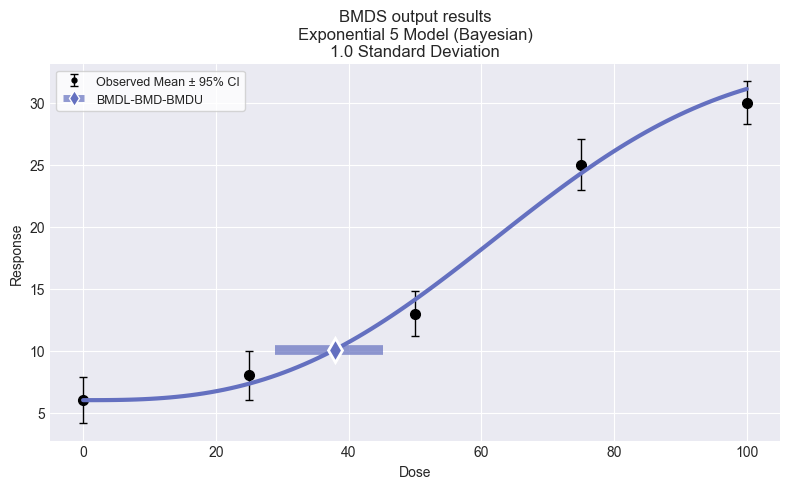

In [6]:
import pybmds
from pybmds.models import continuous

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# Single model fit using LOUD model averaging 
model = continuous.ExponentialM5(
    dataset=dataset,
    settings={"priors": pybmds.PriorClass.bayesian_loud},
)

model.execute()

print(model.text())
fig = model.plot()

## Multiple model fit (sessions) - LOUD

To run LOUD Bayesian model averaging for continuous data using the standard BMDS suite of models, chainging the default MCMC settings to chains = 4, iterations/chain = 12,500, and burn-in/chain = 1,250:

BMD = 37.85 [27.99, 45.36]


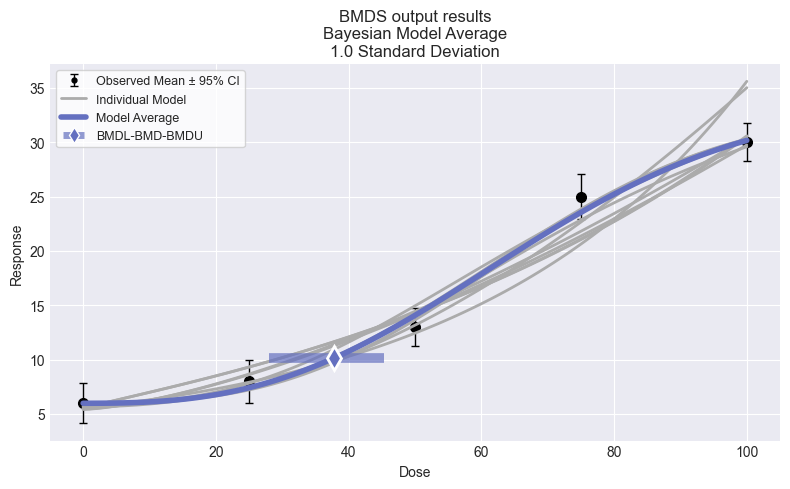

In [7]:
import pybmds

# create a continuous dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

# LOUD model averaging using the standard BMDS continuous suite
session1 = pybmds.Session(dataset=dataset)

settings = {
    "n_chains": 4,
    "samples": 12500,
    "burnin": 1250,
}

session1.add_default_bayesian_models(
    settings=settings,
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=False,  # standard suite only (not PROAST/EFSA-expanded)
)
session1.execute()

# summarize model-averaged result
res1 = session1.model_average.results
print(f"BMD = {res1.bmd:.2f} [{res1.bmdl:.2f}, {res1.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig1 = session1.plot(colorize=False)

confirm the MCMC settings:

In [8]:
model = session1.models[0]  # or whichever model you want to inspect
print("samples:", model.settings.samples)
print("burnin:", model.settings.burnin)
print("n_chains:", model.settings.n_chains)
print("seed:", model.settings.seed)

samples: 12500
burnin: 1250
n_chains: 4
seed: 0


To print the model average distribution plot and BMD distribution overlay plot:

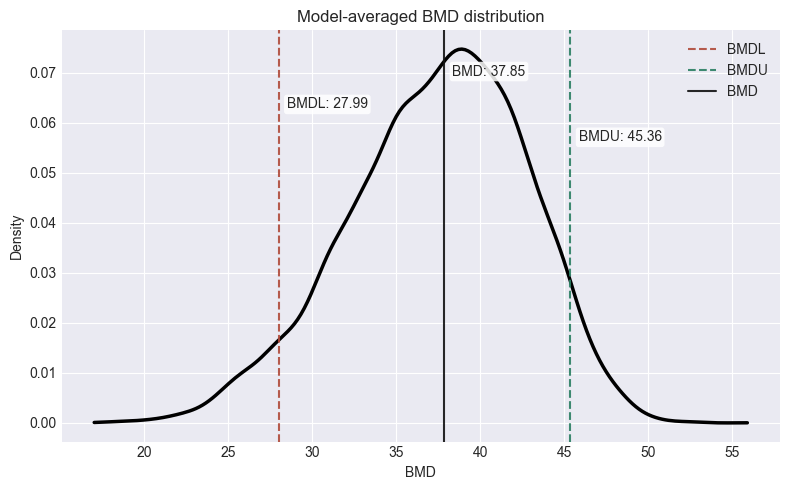

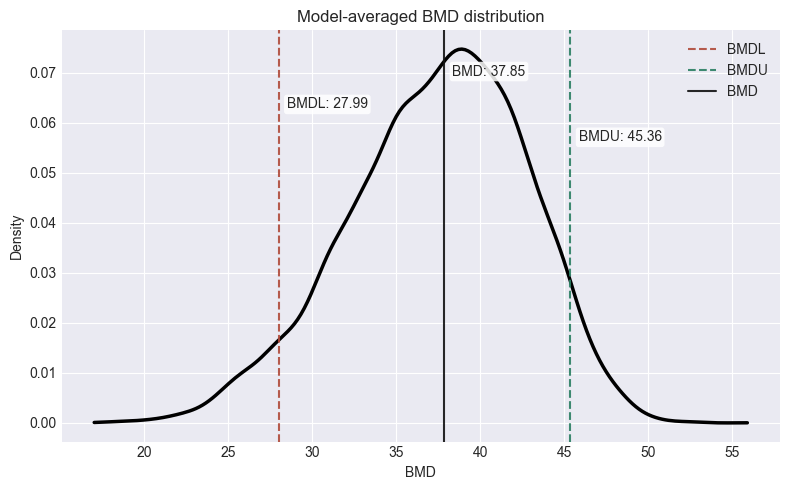

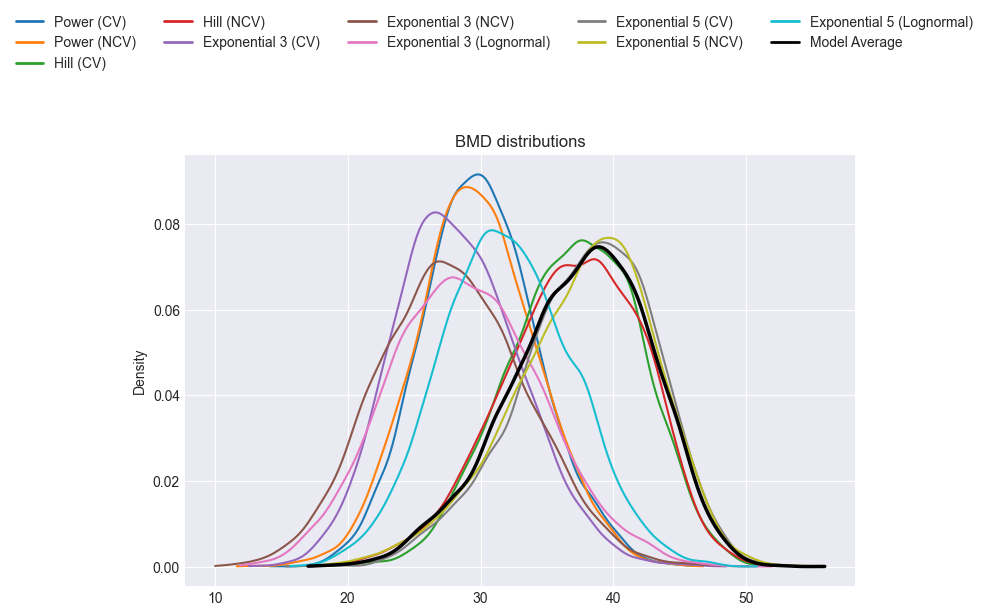

In [14]:
from pybmds.plotting.LOUD import get_model_average_figures
from IPython.display import display

figs1 = get_model_average_figures(session1, compressed=True)

# Show only the model-averaged BMD distribution
display(figs1["posterior"])


To print the trace plots for an individual model:

Trace plot for: Exponential 5 (CV)


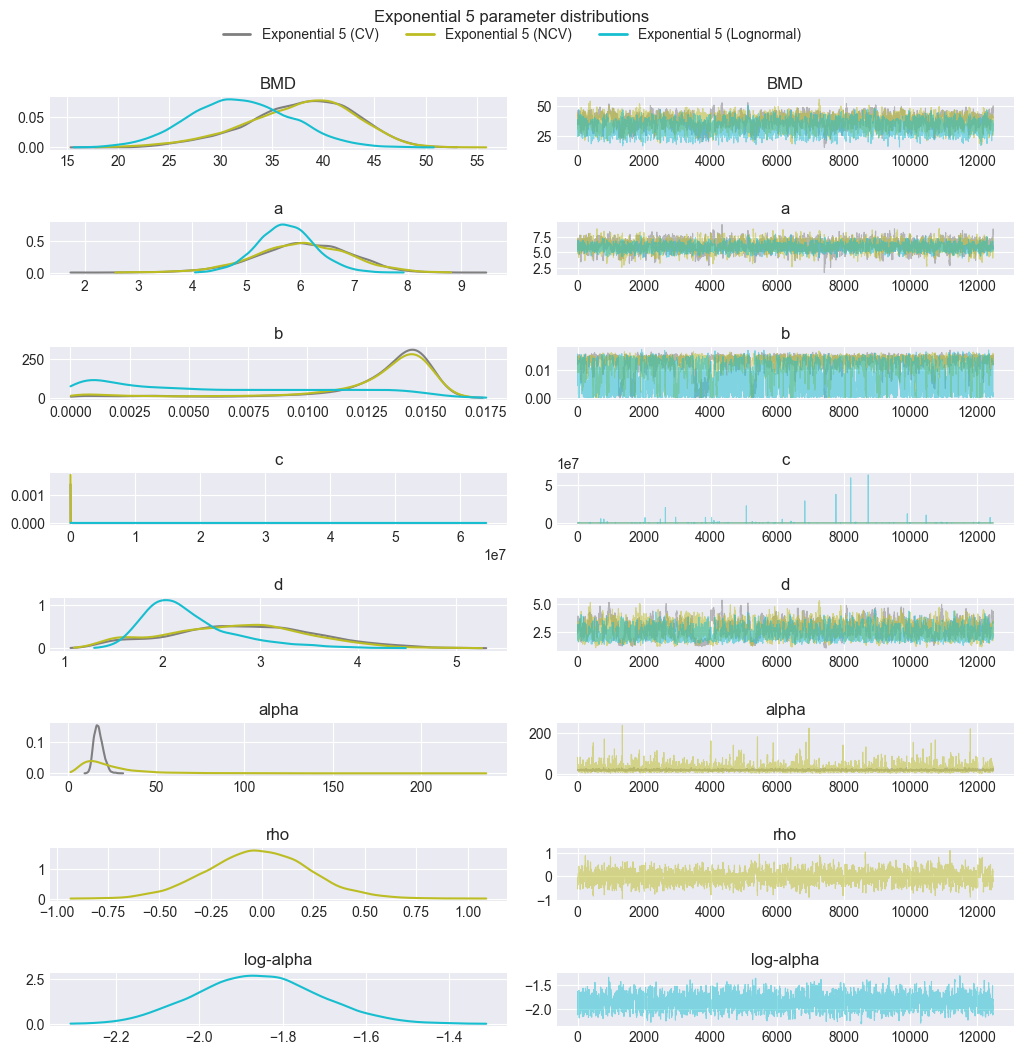

In [15]:
target_model = "Exponential 5 (CV)"

for group in figs1["parameter_groups"]:
    if target_model in group["model_names"]:
        print("Trace plot for:", target_model)
        display(group["trace_figure"])
        break

To print out the MCMC summary table for model-specific BMDs:

In [16]:
display(figs1["bmd_summary"])

,BMD,Median Absolute Deviation,BMDL,BMDU,R-hat,Markov Chain Standard Error (Median),Bulk Effective Sample Size,Tail Effective Sample Size
model,,,,,,,,
Power (CV),29.883490,2.900195,23.088784,37.481667,NaN,0.128196,1312.819805,1624.401662
Power (NCV),29.580987,2.975691,22.472175,37.321352,NaN,0.121084,1471.460359,2222.254606
Hill (CV),37.247565,3.466543,28.655978,44.690118,NaN,0.208405,656.899681,796.664912
Hill (NCV),37.108499,3.689279,27.793591,44.740786,NaN,0.260892,431.142156,630.782285
Exponential 3 (CV),27.982279,3.228683,20.914196,36.423433,NaN,0.170812,720.904196,933.181760
Exponential 3 (NCV),27.706827,3.823831,19.031375,37.086514,NaN,0.179701,1257.228767,1871.945804
Exponential 3 (Lognormal),28.697454,3.938201,19.777735,38.475878,NaN,0.163092,1793.581064,2472.140780
Exponential 5 (CV),38.310564,3.501396,28.570489,45.664974,NaN,0.331733,172.736503,154.757832
Exponential 5 (NCV),38.261078,3.565628,27.893588,45.666661,NaN,0.202866,646.179808,723.408640


To display a summary table of results without MCMC output:

In [17]:
from IPython.display import display

bayes_summary1 = (
session1.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df1 = bayes_summary1
display(df1)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.1,0.004759,23.088784,29.883490,37.481667,0.617944,-0.759919
1,Power (NCV),0.1,0.005803,22.472175,29.580987,37.321352,0.631908,-0.747663
2,Hill (CV),0.1,0.172764,28.655978,37.247565,44.690118,0.023810,0.604371
3,Hill (NCV),0.1,0.140695,27.793591,37.108499,44.740786,0.014954,0.419960
4,Exponential 3 (CV),0.1,0.000122,20.914196,27.982279,36.423433,0.471854,-1.459591
5,Exponential 3 (NCV),0.1,0.000085,19.031375,27.706827,37.086514,0.475790,-1.451337
6,Exponential 3 (Lognormal),0.1,0.000269,19.777735,28.697454,38.475878,-0.290662,-0.813024
7,Exponential 5 (CV),0.1,0.402651,28.570489,38.310564,45.664974,-0.081013,-1.269006
8,Exponential 5 (NCV),0.1,0.267926,27.893588,38.261078,45.666661,-0.040680,-1.427742
9,Exponential 5 (Lognormal),0.1,0.004926,23.923199,31.807242,40.174340,-0.341942,0.261603


### Running Expanded Suite analyses

To run LOUD Bayesian model averaging for continuous data using the expanded suite of models (i.e., BMDS + PROAST + EFSA models) and the same changes to the MCMC settings:

BMD = 44.45 [33.11, 50.02]


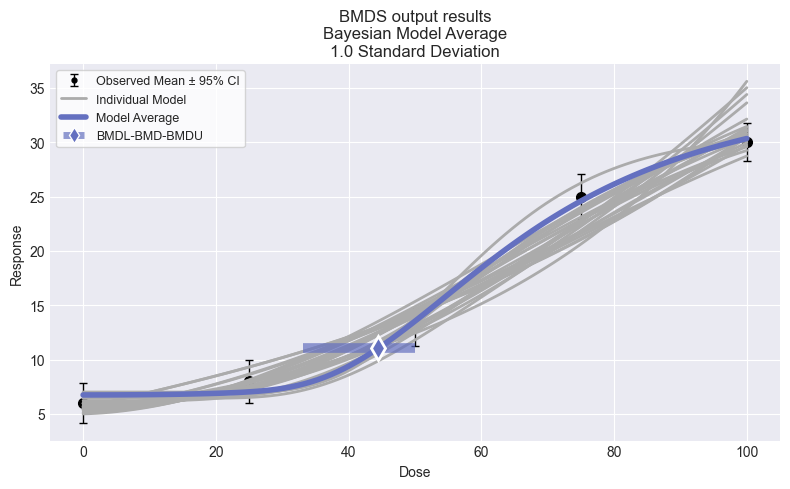

In [18]:
# LOUD model averaging using the expanded BMDS/PROAST/EFSA continuous suite
session2 = pybmds.Session(dataset=dataset)

settings = {
    "n_chains": 4,
    "samples": 12500,
    "burnin": 1250,
}

session2.add_default_bayesian_models(
    settings=settings,
    prior_class=pybmds.PriorClass.bayesian_loud,
    model_average=True,      # add model averaging
    include_extended=True,  # expanded BMDS/PROAST/EFSA suite  
)
session2.execute()

# summarize model-averaged result
res2 = session2.model_average.results
print(f"BMD = {res2.bmd:.2f} [{res2.bmdl:.2f}, {res2.bmdu:.2f}]")

# optional: plot model fits and model-average curve
fig2 = session2.plot(colorize=False)

And to print out a summary table:

In [19]:
bayes_summary2 = (
session2.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df2 = bayes_summary2
display(df2)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Power (CV),0.043478,0.000588,23.088784,29.883490,37.481667,0.617944,-0.759919
1,Power (NCV),0.043478,0.000716,22.472175,29.580987,37.321352,0.631908,-0.747663
2,Exponential 3 (CV),0.043478,0.000015,20.914196,27.982279,36.423433,0.471854,-1.459591
3,Exponential 3 (NCV),0.043478,0.000011,19.031375,27.706827,37.086514,0.475790,-1.451337
4,Exponential 3 (Lognormal),0.043478,0.000033,19.777735,28.697454,38.475878,-0.290662,-0.813024
5,Exponential 5 (CV),0.043478,0.049709,28.570489,38.310564,45.664974,-0.081013,-1.269006
6,Exponential 5 (NCV),0.043478,0.033077,27.893588,38.261078,45.666661,-0.040680,-1.427742
7,Exponential 5 (Lognormal),0.043478,0.000608,23.923199,31.807242,40.174340,-0.341942,0.261603
8,Multiplicative Hill (CV),0.043478,0.021329,28.655978,37.247565,44.690118,0.023810,0.604305
9,Multiplicative Hill (NCV),0.043478,0.017369,27.793591,37.108499,44.740786,0.014999,0.431311


To run LOUD Bayesian model averaging for continuous data using the just the PROAST and EFSA models:

BMD = 44.40 [33.26, 49.91]


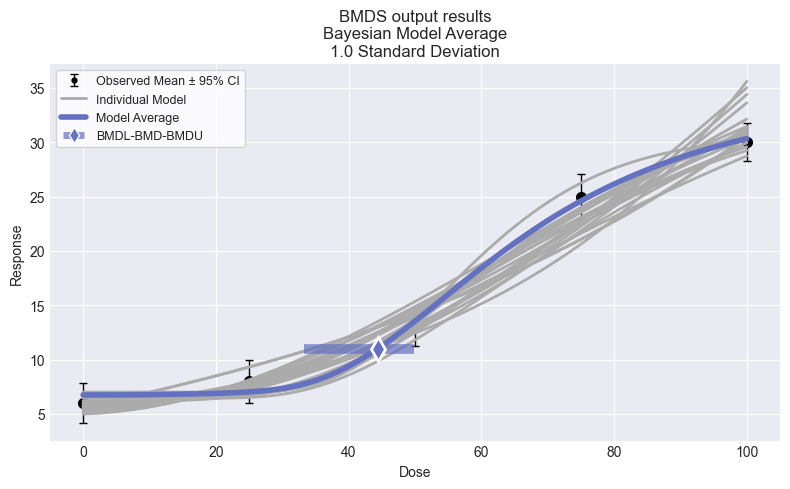

In [20]:
# dataset
dataset = pybmds.ContinuousDataset(
    doses=[0, 25, 50, 75, 100],
    ns=[20, 20, 20, 20, 20],
    means=[6, 8, 13, 25, 30],
    stdevs=[4, 4.3, 3.8, 4.4, 3.7],
)

session3 = pybmds.Session(dataset=dataset)

# Expanded models only (PROAST/EFSA-style set), LOUD priors
expanded_models = [
    pybmds.Models.ExponentialM3,
    pybmds.Models.ExponentialM5,
    pybmds.Models.MultiplicativeHill,
    pybmds.Models.InverseExponential,
    pybmds.Models.Lognormal,
    pybmds.Models.ContinuousGamma,
    pybmds.Models.LMS2,
]

# add all three disttypes (example: constant variance)
dist_types = [
    pybmds.ContinuousDistType.normal,
    pybmds.ContinuousDistType.normal_ncv,
    pybmds.ContinuousDistType.log_normal,
]

for model_name in expanded_models:
    for dt in dist_types:
        session3.add_model(
            model_name,
            settings={
                "n_chains": 4,
                "samples": 12500,
                "burnin": 1250,
                "priors": pybmds.PriorClass.bayesian_loud,
                "disttype": dt,
            },
        )

session3.add_model_averaging()
session3.execute()

res3 = session3.model_average.results
print(f"BMD = {res3.bmd:.2f} [{res3.bmdl:.2f}, {res3.bmdu:.2f}]")
fig3 = session3.plot(colorize=False)

To print a summary table for the EFSA and PROAST models:

In [21]:
bayes_summary3 = (
session3.to_df(clean=False)
[[
"model_name",
"model_prior",
"model_posterior",
"bmdl",
"bmd",
"bmdu",
"residual_at_lowest_dose",
"residual_of_interest",
]]
.rename(columns={
"model_name": "Model",
"model_prior": "Prior Weights",
"model_posterior": "Posterior Weights",
"bmdl": "BMDL",
"bmd": "BMD",
"bmdu": "BMDU",
"residual_at_lowest_dose": "Residual at Control",
"residual_of_interest": "Scaled Residual",
})
)

df3 = bayes_summary3
display(df3)

,Model,Prior Weights,Posterior Weights,BMDL,BMD,BMDU,Residual at Control,Scaled Residual
0,Exponential 3 (CV),0.047619,0.000015,20.914196,27.982279,36.423433,0.471854,-1.459591
1,Exponential 3 (NCV),0.047619,0.000011,19.031375,27.706827,37.086514,0.475790,-1.451337
2,Exponential 3 (Lognormal),0.047619,0.000033,19.777735,28.697454,38.475878,-0.290662,-0.813024
3,Exponential 5 (CV),0.047619,0.049774,28.570489,38.310564,45.664974,-0.081013,-1.269006
4,Exponential 5 (NCV),0.047619,0.033120,27.893588,38.261078,45.666661,-0.040680,-1.427742
5,Exponential 5 (Lognormal),0.047619,0.000609,23.923199,31.807242,40.174340,-0.341942,0.261603
6,Multiplicative Hill (CV),0.047619,0.021356,28.655978,37.247565,44.690118,0.023810,0.604305
7,Multiplicative Hill (NCV),0.047619,0.017392,27.793591,37.108499,44.740786,0.014999,0.431311
8,Multiplicative Hill (Lognormal),0.047619,0.000610,23.321178,31.219543,39.066474,-0.449881,0.238462
9,Inverse Exponential (CV),0.047619,0.256608,38.302018,44.312054,48.648312,-0.976098,-0.646615


To compare the model averaged results for all three analyses using different model suites:

In [22]:
import pandas as pd

def ma_point_summary(session, label):
    if session.model_average is None:
        raise ValueError(f"{label} has no model average.")
    r = session.model_average.results
    return {
        "Session": label,
        "BMDL": float(r.bmdl),
        "BMD": float(r.bmd),
        "BMDU": float(r.bmdu),
    }

comparison = pd.DataFrame([
    ma_point_summary(session1, "Session 1 (BMDS only)"),
    ma_point_summary(session2, "Session 2 (BMDS + Expanded)"),
    ma_point_summary(session3, "Session 3 (Expanded only)"),
])

comparison

,Session,BMDL,BMD,BMDU
0,Session 1 (BMDS only),27.985880,37.847728,45.361620
1,Session 2 (BMDS + Expanded),33.108711,44.451944,50.015819
2,Session 3 (Expanded only),33.257057,44.403430,49.914704
